# Project 3: Design and Implementation of a Sign Language Image Classifier
## Phase 1

### 0. Importation!

In [ ]:
#we import the libraries we need in our project
import os
import random
import sys
import subprocess
import pathlib
import copy

def install_package(package_name):
    print(f"Installing package '{package_name}'... Please wait.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# Loading Phase 1 Libraries

try:
    import cv2
except ImportError:
    install_package('opencv-python')
    import cv2

try:
    import numpy as np
except ImportError:
    install_package('numpy')
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    install_package('matplotlib')
    import matplotlib.pyplot as plt

try:
    from sklearn.model_selection import train_test_split
except ImportError:
    install_package('scikit-learn')
    from sklearn.model_selection import train_test_split

# Loading Phase 2 Libraries

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
except ImportError:
    install_package('torch')
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader

try:
    import torchvision.transforms as transforms
except ImportError:
    install_package('torchvision')
    import torchvision.transforms as transforms

try:
    from sklearn.metrics import confusion_matrix
except ImportError:
    install_package('scikit-learn')
    from sklearn.metrics import confusion_matrix


# Set default plot style
plt.style.use('ggplot')
print("\nAll imports for Phase 1 and Phase 2 are successfully completed!")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


All imports for Phase 1 and Phase 2 are successfully completed!
Using device: cuda


### 1. Data Loading and Exploration (EDA)
In this section, we define the dataset path and check if the data is balanced. To do this, we plot the number of samples per class using a bar chart.

Total number of classes: 29

Minimum samples in a class: 3000
Maximum samples in a class: 3000
The dataset is perfectly balanced!



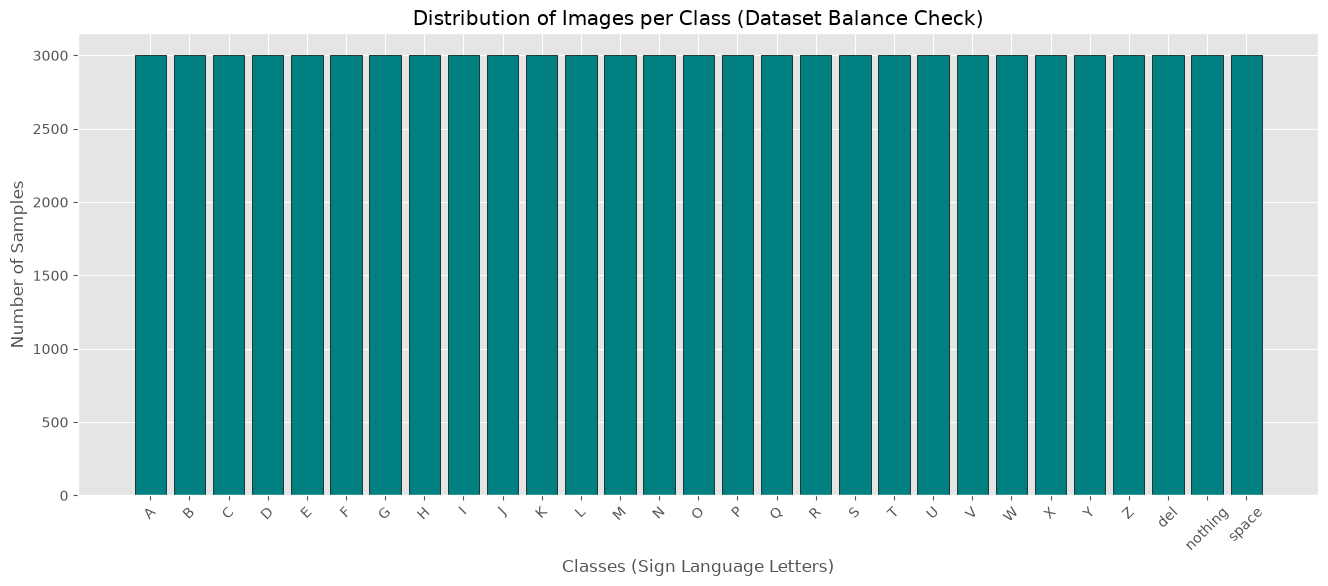

In [2]:
# Dataset path
dataset_path = r'alphabet/asl_alphabet_train/asl_alphabet_train'
classes = sorted(os.listdir(dataset_path))
print(f"Total number of classes: {len(classes)}\n")

# we here count the total number of images for each class
class_counts = {}
for c in classes:
    class_path = os.path.join(dataset_path, c)
    if os.path.isdir(class_path):
        class_counts[c] = len(os.listdir(class_path))

# Check if they are equal in each class or not
min_samples = min(class_counts.values())
max_samples = max(class_counts.values())
print(f"Minimum samples in a class: {min_samples}")
print(f"Maximum samples in a class: {max_samples}")

if min_samples == max_samples:
    print("they are equal in every classes\n")
else:
    print("The dataset images are not totally equeld in every classes.\n")

# Plot
plt.figure(figsize=(16, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='teal', edgecolor='black')
plt.title('Distribution of Images per Class (Dataset Balance Check)')
plt.xlabel('Classes (Sign Language Letters)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

### 2. Sample Visualization
To better understand the dataset, we randomly select one image from each class and display it along with its label in a grid.

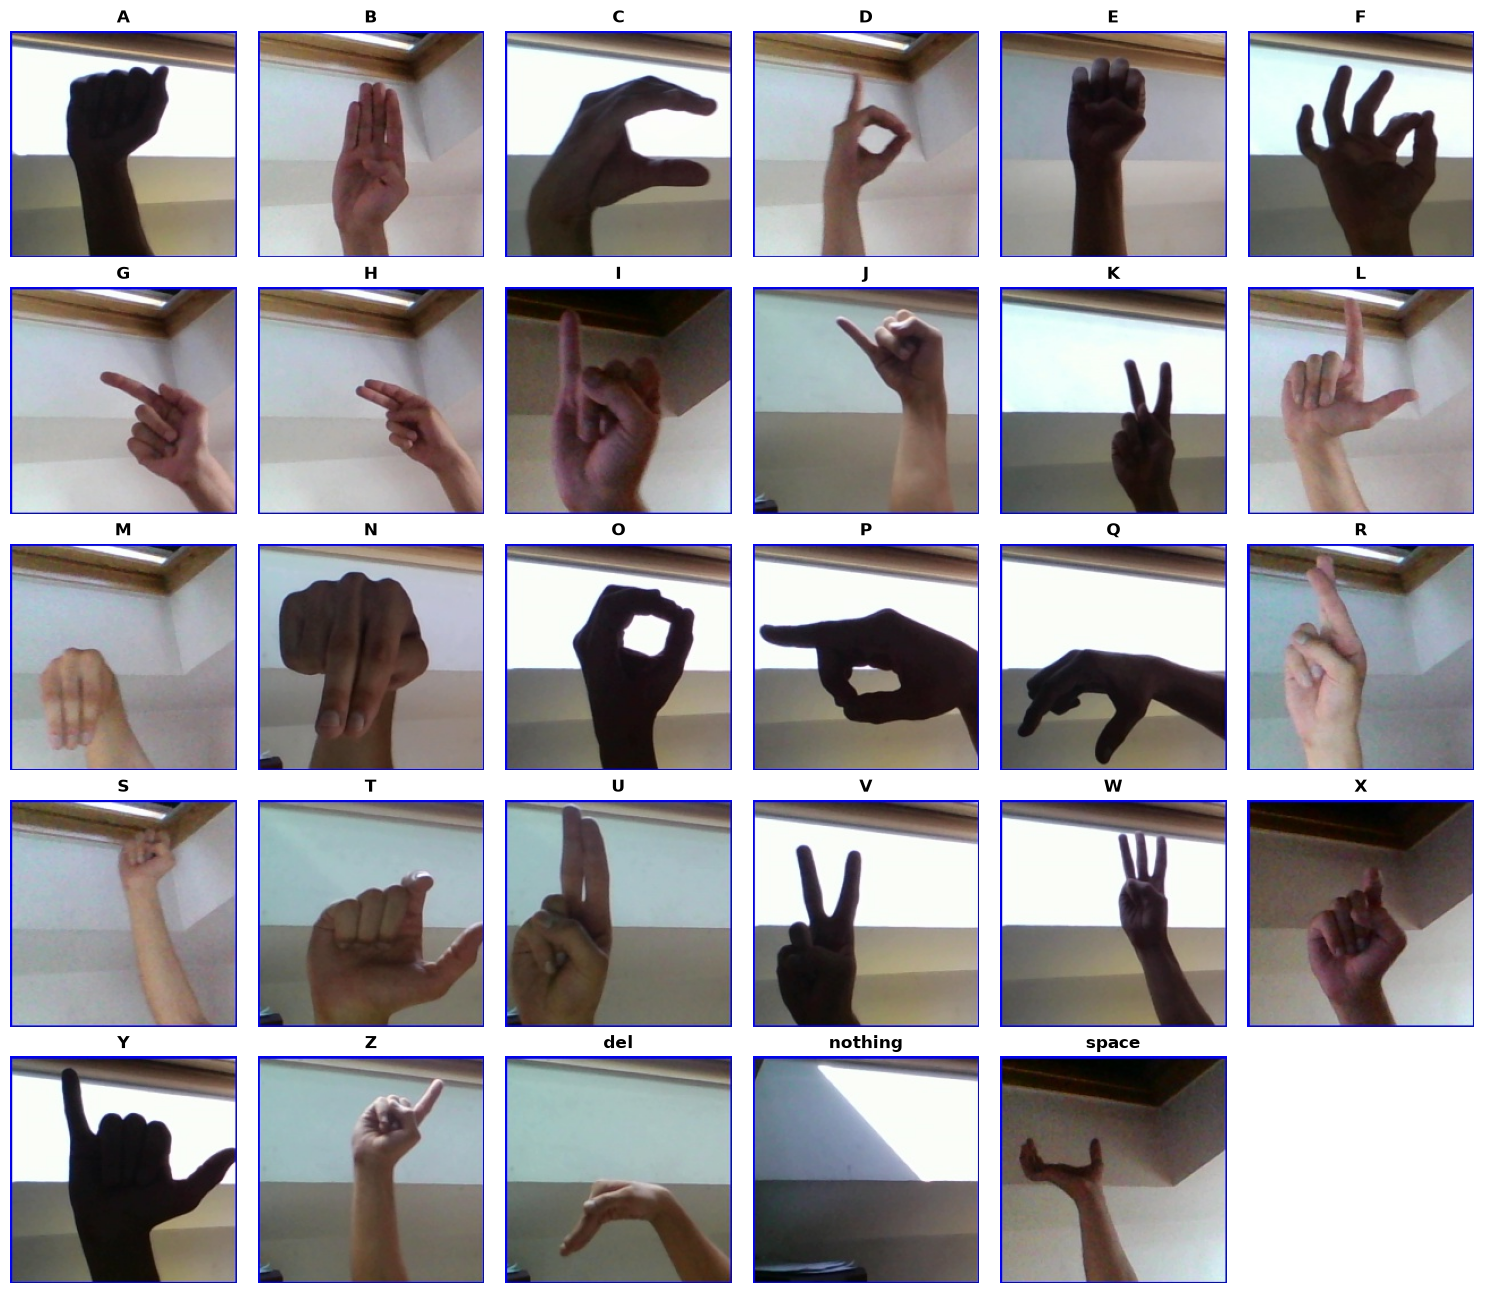

In [3]:
# we want to show the pictures in 5 * 6 gird
fig, axes = plt.subplots(5, 6, figsize=(15, 13))
axes = axes.flatten()

#for each class get the random picture and show it
for i, c in enumerate(classes):
    class_path = os.path.join(dataset_path, c)
    images = os.listdir(class_path)
    
    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(img)
    axes[i].set_title(c, fontsize=12, fontweight='bold')
    axes[i].axis('off')

for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 3. Data Splitting and Preprocessing Function
Images must be standardized before feeding them into the neural network. We will write a function to resize them (e.g., to 64x64) and normalize pixel values to the [0, 1] range. Then, we will split the entire dataset using the standard 80% Train, 10% Validation, and 10% Test ratio.

In [4]:
#here we first store all adresses and all the classes per each address in the labels
filepaths = []
labels = []
for c in classes:
    class_path = os.path.join(dataset_path, c)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            filepaths.append(os.path.join(class_path, img_name))
            labels.append(c)

#here we split the total picturs in to the train - valid - test parts
# 80% for train and 10% for each valid and test 
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.20, random_state=42, stratify=labels
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

#this lines are extra just for be sure it is true partition 
print(f"Training data count: {len(X_train_paths)}")
print(f"Validation data count: {len(X_val_paths)}")
print(f"Test data count: {len(X_test_paths)}\n")


#here is the function witch we make the picture standard for phase 2
def preprocess_image(image_path, size=(64, 64)):    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    #resizing the picture
    img_resized = cv2.resize(img, size)
    
    # Normalize pixel values( put it beetween 0 and 1)
    img_normalized = img_resized.astype(np.float32) / 255.0 
    return img_normalized


# Apply preprocessing to all image paths for Train, Validation, and Test parts
print("Preprocessing training images...")
X_train = np.array([preprocess_image(p) for p in X_train_paths])

print("Preprocessing validation images...")
X_val = np.array([preprocess_image(p) for p in X_val_paths])

print("Preprocessing test images...")
X_test = np.array([preprocess_image(p) for p in X_test_paths])

#this parts are Extra just for confidence 
print(f"\nX_train shape: {X_train.shape} | Min: {X_train.min():.1f}, Max: {X_train.max():.1f}")
print(f"X_val shape:   {X_val.shape}   | Min: {X_val.min():.1f}, Max: {X_val.max():.1f}")
print(f"X_test shape:  {X_test.shape}  | Min: {X_test.min():.1f}, Max: {X_test.max():.1f}")
sample_img = preprocess_image(X_train_paths[0], size=(64, 64))
print(f"Output image shape after preprocessing: {sample_img.shape}")
print(f"Min pixel value: {sample_img.min():.1f} | Max pixel value: {sample_img.max():.1f}")

Training data count: 69600
Validation data count: 8700
Test data count: 8700

Preprocessing training images...
Preprocessing validation images...
Preprocessing test images...

X_train shape: (69600, 64, 64, 3) | Min: 0.0, Max: 1.0
X_val shape:   (8700, 64, 64, 3)   | Min: 0.0, Max: 1.0
X_test shape:  (8700, 64, 64, 3)  | Min: 0.0, Max: 1.0
Output image shape after preprocessing: (64, 64, 3)
Min pixel value: 0.0 | Max pixel value: 1.0


## Phase 2

### 1. Data Augmentation and Advanced DataLoader Preparation
In this section, we introduce **Data Augmentation** techniques to enhance the model's generalization and prevent overfitting. We map the string labels to numerical indices and convert the NumPy arrays into PyTorch tensors, actively reshaping them to the `(Batch, Channels, Height, Width)` format required by PyTorch. 

We implement a `CustomTensorDataset` to apply transformations dynamically. Finally, `DataLoaders` are configured with `pin_memory=True` to drastically accelerate data transfer from RAM to the GPU (CUDA).

In [ ]:
# Data Augmentation for train
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))
])

# Dataset
class CustomTensorDataset(Dataset):
    def __init__(self, tensors, labels, transform=None):
        self.tensors = tensors
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        x = self.tensors[index]
        y = self.labels[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return self.tensors.size(0)

# Map class to indices
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

# Convert string labels to integer tensors
y_train_idx = torch.tensor([class_to_idx[l] for l in y_train], dtype=torch.long)
y_val_idx = torch.tensor([class_to_idx[l] for l in y_val], dtype=torch.long)
y_test_idx = torch.tensor([class_to_idx[l] for l in y_test], dtype=torch.long)

# Convert NumPy arrays to PyTorch tensors and permute dimensions from (N, H, W, C) to (N, C, H, W)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

# Make datasets
train_dataset = CustomTensorDataset(X_train_tensor, y_train_idx, transform=train_transforms)
val_dataset = CustomTensorDataset(X_val_tensor, y_val_idx, transform=None)
test_dataset = CustomTensorDataset(X_test_tensor, y_test_idx, transform=None)

BATCH_SIZE = 64

# GPU
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0,         
    pin_memory=True        
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

NameError: name 'transforms' is not defined

### 2. CNN Architecture
Here we create our CNN model. It has 4 convolution blocks, then adaptive pooling and fully connected layers. In the `forward` function, we use `F.relu` for activation. Also, we add `BatchNorm` for stable training and `Dropout` to stop overfitting. At the end, we make the model, send it to GPU or CPU, and count its parameters.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes=29):
        super(CNN, self).__init__()

        # Block 1: Input (3) -> 32 channels
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.dropout2d_1 = nn.Dropout2d(p=0.10)

        # Block 2: 32 -> 64 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.dropout2d_2 = nn.Dropout2d(p=0.15)

        # Block 3: 64 -> 128 channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout2d_3 = nn.Dropout2d(p=0.20)

        # Block 4: 128 -> 256 channels
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.dropout2d_4 = nn.Dropout2d(p=0.25)

        # Shared Max Pooling layer for all blocks
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Adaptive Pooling: Resizes output to 2x2
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # Fully Connected 1: 1024 -> 256
        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout_fc = nn.Dropout(p=0.50)

        # Fully Connected 2 (Output Layer): 256 -> 29 classes
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout2d_1(x)

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout2d_2(x)

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout2d_3(x)

        # Block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.dropout2d_4(x)

        # Adaptive Pooling & Flatten
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        # Fully Connected 1
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc(x)

        # Fully Connected 2 (Output)
        x = self.fc2(x)

        return x

# Instantiate the model and move it to the configured device (GPU/CPU)
model = CNN(num_classes=len(classes)).to(device)

print(model)
parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model Parameters: {parameters:,} (All Trainable)")

SignLanguageCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2d_1): Dropout2d(p=0.1, inplace=False)
  (dropout2d_2): Dropout2d(p=0.15, inplace=False)
  (dropout2d_3): Dropout2d(p=0.2, inplace=False)
  (dropout2d_4): Dropout2d(p=0.25, inplace=False)
  (adaptive_pool): AdaptiveAvgPo

### 3. Hyperparameter Optimization & Model Training
Initializing the `AdamW` optimizer and executing the epoch-based training and validation loops with dynamic learning rate adjustments.

In [ ]:
# Hyperparameters
LEARNING_RATE = 0.001
EPOCHS = 12
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Reduce learning rate if validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# Lists of loss and accuracy
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# best model
best_val_loss = float('inf')
best_model_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

print(f"Training started with LR = {LEARNING_RATE}, Epochs = {EPOCHS}...\n")

for epoch in range(EPOCHS):
    # Training
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Calculate new gradients
        loss.backward()

        # Clip gradients to prevent them from exploding
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

         # Update weights
        optimizer.step()

        # Calculate accuracy and loss
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

     # Don't calculate gradients here
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calculate accuracy and loss
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # Update Learning Rate
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # If model is better, save its weights
    if epoch_val_loss < best_val_loss - 1e-4:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        best_marker = " <-- best model"
    else:
        epochs_without_improvement += 1
        best_marker = ""

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}% | "
        f"LR: {current_lr:.6f}{best_marker}"
    )

    # Stop training if model is not improving anymore
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.4f}")
        break

# Restore the best model weights before finishing
model.load_state_dict(best_model_state)
print("\nTraining completed! Best model restored.")

Training started with Learning Rate = 0.001, Weight Decay = 0.0001, and maximum 12 epochs...

Epoch [1/12] | Train Loss: 1.5446 - Train Acc: 52.63% | Val Loss: 0.2578 - Val Acc: 93.72% | LR: 0.001000 <-- best model
Epoch [2/12] | Train Loss: 0.4674 - Train Acc: 84.42% | Val Loss: 0.0994 - Val Acc: 96.54% | LR: 0.001000 <-- best model
Epoch [3/12] | Train Loss: 0.2633 - Train Acc: 91.09% | Val Loss: 0.0336 - Val Acc: 99.23% | LR: 0.001000 <-- best model
Epoch [4/12] | Train Loss: 0.1805 - Train Acc: 94.11% | Val Loss: 0.0194 - Val Acc: 99.33% | LR: 0.001000 <-- best model
Epoch [5/12] | Train Loss: 0.1468 - Train Acc: 95.16% | Val Loss: 0.0131 - Val Acc: 99.51% | LR: 0.001000 <-- best model
Epoch [6/12] | Train Loss: 0.1219 - Train Acc: 96.03% | Val Loss: 0.0100 - Val Acc: 99.77% | LR: 0.001000 <-- best model
Epoch [7/12] | Train Loss: 0.1058 - Train Acc: 96.47% | Val Loss: 0.0078 - Val Acc: 99.82% | LR: 0.001000 <-- best model
Epoch [8/12] | Train Loss: 0.0969 - Train Acc: 96.73% | Val

### 4. Plotting Loss and Accuracy Curves
Visualizing the model's performance on both training and validation sets.

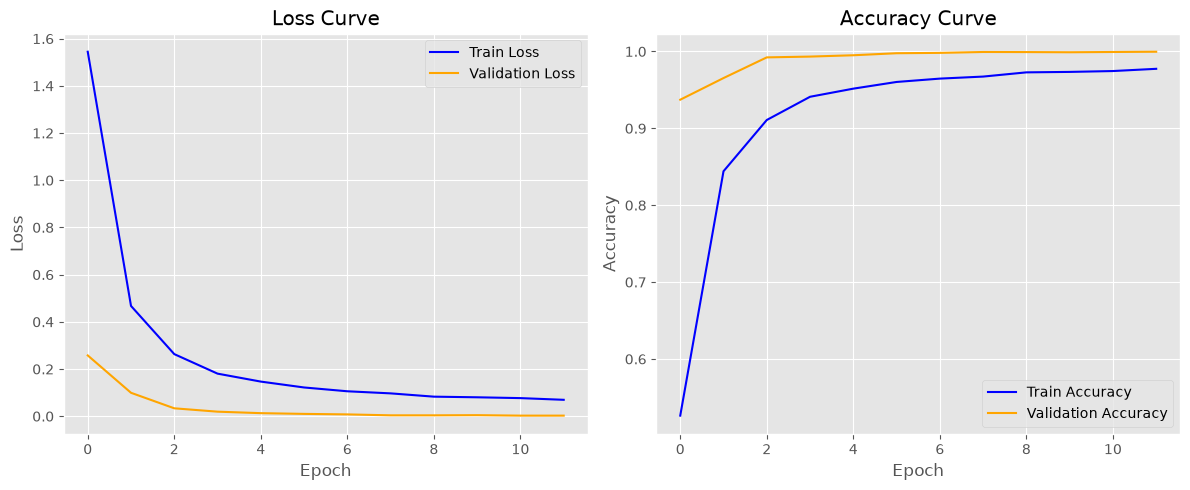

In [9]:
plt.figure(figsize=(12, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 5. Model Evaluation & Confusion Matrix
Evaluating the trained model on the unseen test dataset and plotting the confusion matrix to identify misclassified sign language characters.

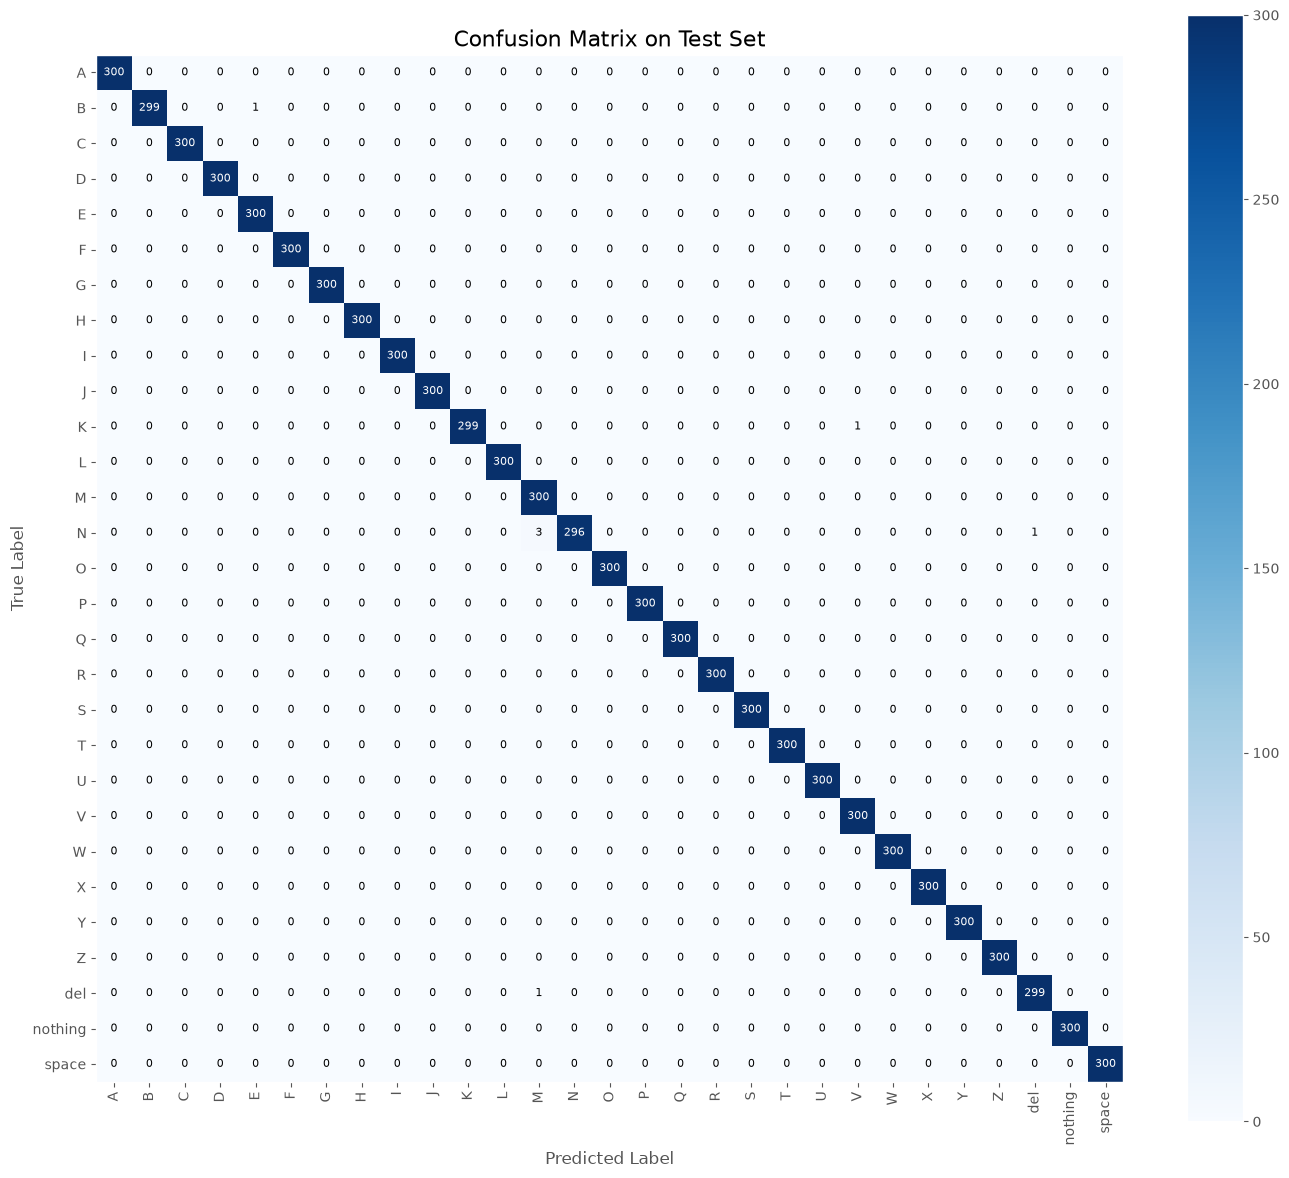

In [14]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        # Transfer predictions back to CPU for plotting
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())

# Calculate Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot Confusion Matrix
plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set', fontsize=16) 
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=8)

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

### 6. Saving the Trained Model
After successfully training and evaluating the model, we save its learned weights (state_dict) to a `.pth` file. This allows us to load the trained model later for inference (e.g., live webcam prediction) without needing to retrain it.

In [ ]:
# Define the path to save the model
MODEL_PATH = 'sign_language_cnn_model.pth'

# Save the model's state dictionary (weights and biases)
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model weights successfully saved to: {os.path.abspath(MODEL_PATH)}")

Model weights successfully saved to: p:\AI-Project\sign_language_cnn_model.pth
